<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Computer%20Vision/CLIP%20%C3%A9s%20Multimod%C3%A1lis%20Tanul%C3%A1s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLIP és Multimodális Tanulás

A **CLIP** (Contrastive Language-Image Pre-training) egy multimodális modell, amely **képeket és szöveget** közös reprezentációs térbe képez le. Ez lehetővé teszi a zero-shot képosztályozást és a szemantikus képkeresést.

## Fő ötlet

Képek és azok szöveges leírásai → Kontraszt tanulás → Közös embedding tér

```
"egy kutya a parkban"  ───▶  [Text Encoder]  ───▶  ┐
                                                   ├──▶  Cosine hasonlóság
[kutya kép]            ───▶  [Image Encoder] ───▶  ┘
```

## Tartalomjegyzék

1. CLIP architektúra
2. Kontraszt tanulás képekre és szövegre
3. Zero-shot osztályozás
4. Képkeresés szöveggel
5. CLIP alkalmazások

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
torch.manual_seed(42)

## 1. CLIP architektúra

### Két encoder, egy tér

```
┌─────────────────────────────────────────────────────────┐
│                                                         │
│   Kép ──▶ [Image Encoder] ──▶ Image Embedding (512d)    │
│                                       ↓                 │
│                               Közös embedding tér       │
│                                       ↑                 │
│  Szöveg ──▶ [Text Encoder] ──▶ Text Embedding (512d)    │
│                                                         │
└─────────────────────────────────────────────────────────┘
```

### Encoder választások

| Komponens | Lehetőségek |
|-----------|-------------|
| Image Encoder | ResNet-50, ViT-B/32, ViT-L/14 |
| Text Encoder | Transformer (GPT-style) |

In [2]:
class SimpleCLIP(nn.Module):
    """
    Egyszerűsített CLIP modell demonstrációhoz.
    """
    def __init__(self, embed_dim=256, image_dim=512, text_vocab=1000, text_dim=256):
        super().__init__()

        # Image Encoder (egyszerűsített CNN)
        self.image_encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, 2, 1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, embed_dim)
        )

        # Text Encoder (egyszerűsített)
        self.text_embedding = nn.Embedding(text_vocab, text_dim)
        self.text_encoder = nn.Sequential(
            nn.Linear(text_dim, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim)
        )

        # Learnable temperature
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def encode_image(self, image):
        features = self.image_encoder(image)
        return F.normalize(features, dim=-1)

    def encode_text(self, text_tokens):
        # Átlag pooling a tokenekre
        x = self.text_embedding(text_tokens)  # [B, seq_len, dim]
        x = x.mean(dim=1)  # [B, dim]
        features = self.text_encoder(x)
        return F.normalize(features, dim=-1)

    def forward(self, images, texts):
        image_features = self.encode_image(images)
        text_features = self.encode_text(texts)

        # Cosine hasonlóság (logit scale-el)
        logit_scale = self.logit_scale.exp()
        logits_per_image = logit_scale * image_features @ text_features.t()
        logits_per_text = logits_per_image.t()

        return logits_per_image, logits_per_text

# Teszt
clip_model = SimpleCLIP()
images = torch.randn(4, 3, 64, 64)
texts = torch.randint(0, 1000, (4, 10))  # 4 szöveg, max 10 token

logits_i, logits_t = clip_model(images, texts)
print(f"Image-Text logits: {logits_i.shape}")
print(f"  → Minden kép hasonlósága minden szöveghez")

Image-Text logits: torch.Size([4, 4])
  → Minden kép hasonlósága minden szöveghez


## 2. Kontraszt tanulás

### CLIP loss

Egy batch-ben az $i$-edik kép az $i$-edik szöveggel alkot pozitív párt.

$$\mathcal{L} = \frac{1}{2}\left(\mathcal{L}_{image} + \mathcal{L}_{text}\right)$$

$$\mathcal{L}_{image} = -\frac{1}{N}\sum_{i=1}^{N} \log \frac{\exp(s_{i,i}/\tau)}{\sum_{j=1}^{N} \exp(s_{i,j}/\tau)}$$

ahol $s_{i,j}$ a kép $i$ és szöveg $j$ közötti cosine hasonlóság.

C:\Users\Balint\AppData\Local\Temp\ipykernel_32\1541652462.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


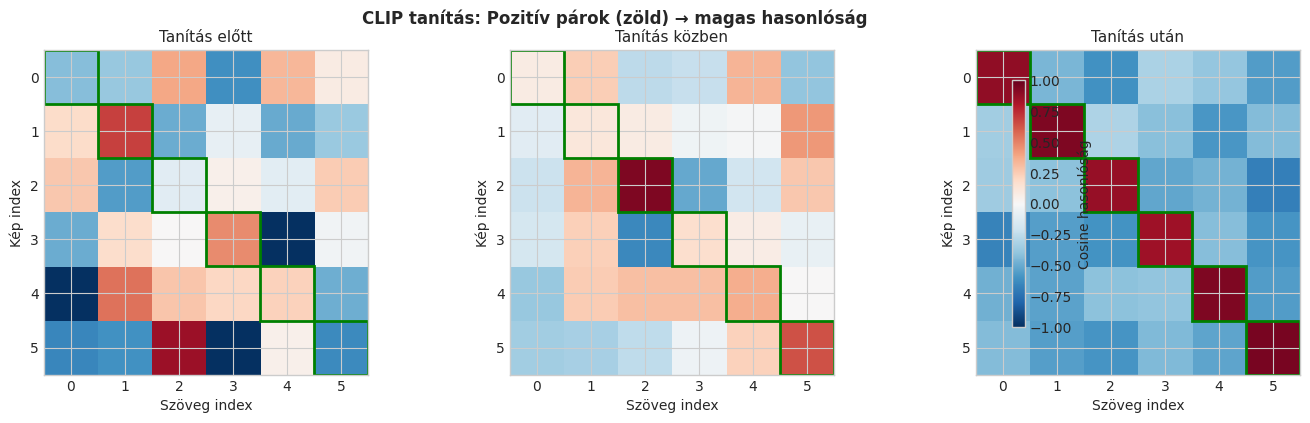

In [3]:
def clip_loss(logits_per_image, logits_per_text):
    """
    CLIP kontraszt loss.

    A diagonális elemek a pozitív párok (kép_i ↔ szöveg_i).
    """
    batch_size = logits_per_image.shape[0]
    labels = torch.arange(batch_size)

    # Cross-entropy mindkét irányban
    loss_i = F.cross_entropy(logits_per_image, labels)
    loss_t = F.cross_entropy(logits_per_text, labels)

    return (loss_i + loss_t) / 2

# Vizualizáció: Batch hasonlóság mátrix
def visualize_clip_batch(n_samples=6):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Szimulált hasonlóság mátrixok
    # 1. Tanítás előtt (random)
    random_sim = np.random.randn(n_samples, n_samples) * 0.5

    # 2. Tanítás közben
    mid_sim = np.random.randn(n_samples, n_samples) * 0.3
    for i in range(n_samples):
        mid_sim[i, i] += 0.5  # Diagonális erősítése

    # 3. Tanítás után
    trained_sim = np.random.randn(n_samples, n_samples) * 0.1 - 0.5
    for i in range(n_samples):
        trained_sim[i, i] = 0.9 + np.random.randn() * 0.05

    for ax, sim, title in zip(axes,
                              [random_sim, mid_sim, trained_sim],
                              ['Tanítás előtt', 'Tanítás közben', 'Tanítás után']):
        im = ax.imshow(sim, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_xlabel('Szöveg index')
        ax.set_ylabel('Kép index')
        ax.set_title(title, fontsize=11)

        # Diagonális kiemelése
        for i in range(n_samples):
            ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1,
                                       fill=False, edgecolor='green', linewidth=2))

    plt.colorbar(im, ax=axes, label='Cosine hasonlóság', shrink=0.8)
    plt.suptitle('CLIP tanítás: Pozitív párok (zöld) → magas hasonlóság',
                fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_clip_batch()

## 3. Zero-shot osztályozás

A CLIP egyik legfontosabb képessége: **új osztályokra is működik** anélkül, hogy látta volna őket tanítás közben!

### Hogyan működik?

1. Szöveges osztálycímkék → Text embedding ("a photo of a dog", "a photo of a cat", ...)
2. Új kép → Image embedding
3. Osztály = Legmagasabb hasonlóság

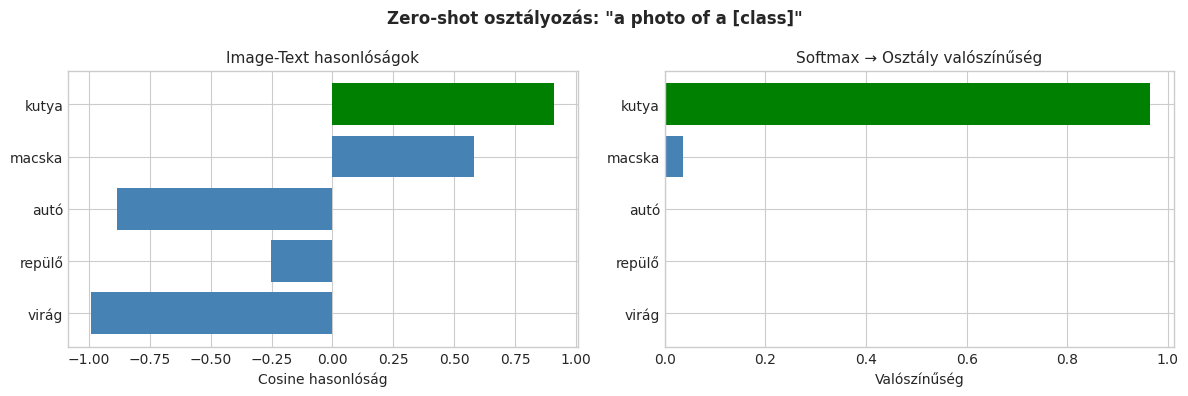

Predikció: kutya (96.4%)


In [4]:
def zero_shot_classification_demo():
    """
    Zero-shot osztályozás koncepció.
    """
    # Szimulált embeddings
    classes = ['kutya', 'macska', 'autó', 'repülő', 'virág']

    # "Tanult" text embeddings (szimulált)
    np.random.seed(42)
    text_embeddings = np.random.randn(len(classes), 4)
    text_embeddings = text_embeddings / np.linalg.norm(text_embeddings, axis=1, keepdims=True)

    # Új kép embedding (szimulált - hasonlít a kutyához)
    image_embedding = text_embeddings[0] + np.random.randn(4) * 0.2
    image_embedding = image_embedding / np.linalg.norm(image_embedding)

    # Hasonlóságok
    similarities = image_embedding @ text_embeddings.T
    probs = F.softmax(torch.tensor(similarities) * 10, dim=0).numpy()

    # Vizualizáció
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Hasonlóság
    colors = ['green' if i == np.argmax(similarities) else 'steelblue' for i in range(len(classes))]
    axes[0].barh(classes, similarities, color=colors)
    axes[0].set_xlabel('Cosine hasonlóság')
    axes[0].set_title('Image-Text hasonlóságok', fontsize=11)

    # Valószínűségek
    axes[1].barh(classes, probs, color=colors)
    axes[1].set_xlabel('Valószínűség')
    axes[1].set_title('Softmax → Osztály valószínűség', fontsize=11)

    for ax in axes:
        ax.invert_yaxis()

    plt.suptitle('Zero-shot osztályozás: "a photo of a [class]"',
                fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Predikció: {classes[np.argmax(probs)]} ({probs.max():.1%})")

zero_shot_classification_demo()

In [5]:
# Prompt engineering hatása
def prompt_engineering_demo():
    """Különböző prompt template-ek hatása."""

    templates = [
        "a photo of a {}",
        "a picture of a {}",
        "a {} in the wild",
        "a professional photo of a {}",
        "a blurry photo of a {}",
    ]

    class_name = "golden retriever"

    print("Prompt Engineering példák:")
    print("=" * 50)
    for template in templates:
        prompt = template.format(class_name)
        print(f"  '{prompt}'")

    print("\n💡 Tipp: Több template átlagolása javítja a pontosságot!")

prompt_engineering_demo()

Prompt Engineering példák:
  'a photo of a golden retriever'
  'a picture of a golden retriever'
  'a golden retriever in the wild'
  'a professional photo of a golden retriever'
  'a blurry photo of a golden retriever'

💡 Tipp: Több template átlagolása javítja a pontosságot!


## 4. Képkeresés szöveggel

CLIP lehetővé teszi a **szemantikus képkeresést**: szöveges lekérdezéssel keresünk képeket.

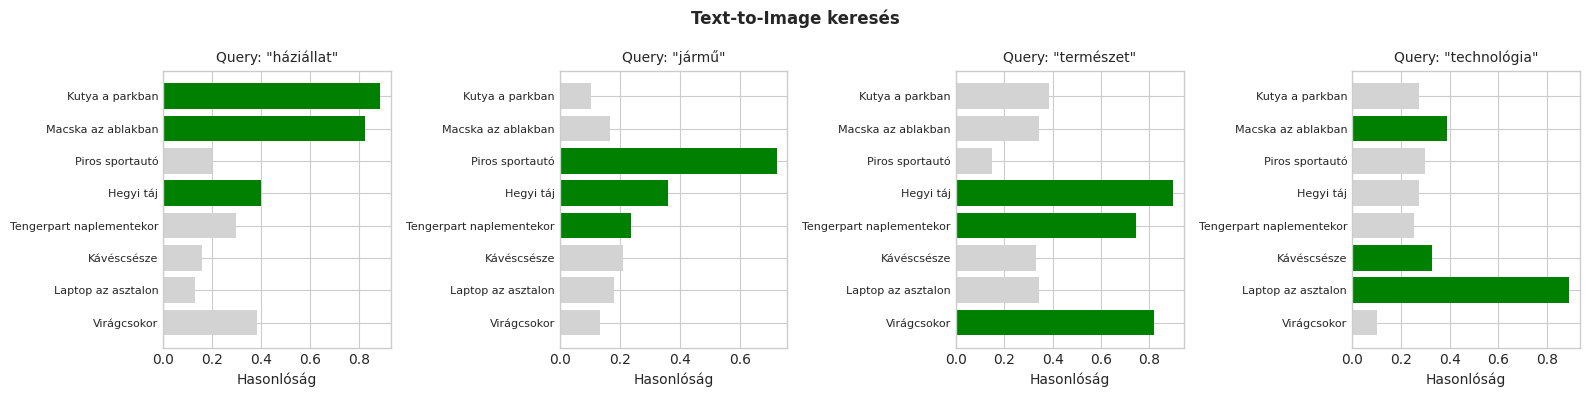

In [6]:
def text_to_image_search_demo():
    """Képkeresés szöveges lekérdezéssel."""

    # Szimulált képadatbázis
    image_descriptions = [
        "Kutya a parkban",
        "Macska az ablakban",
        "Piros sportautó",
        "Hegyi táj",
        "Tengerpart naplementekor",
        "Kávéscsésze",
        "Laptop az asztalon",
        "Virágcsokor",
    ]

    # Szimulált embeddings
    np.random.seed(123)
    image_embeddings = np.random.randn(len(image_descriptions), 64)
    image_embeddings = image_embeddings / np.linalg.norm(image_embeddings, axis=1, keepdims=True)

    # Lekérdezések
    queries = ["háziállat", "jármű", "természet", "technológia"]

    # Query embeddings (szimulált - hasonló témájúakhoz közel)
    query_to_related = {
        "háziállat": [0, 1],    # kutya, macska
        "jármű": [2],           # autó
        "természet": [3, 4, 7], # hegyi táj, tengerpart, virág
        "technológia": [6],     # laptop
    }

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for ax, query in zip(axes, queries):
        # Szimulált hasonlóságok
        related_indices = query_to_related[query]
        similarities = np.random.rand(len(image_descriptions)) * 0.3 + 0.1
        for idx in related_indices:
            similarities[idx] = 0.7 + np.random.rand() * 0.2

        # Top-3
        top_indices = np.argsort(similarities)[::-1][:3]

        colors = ['green' if i in top_indices else 'lightgray'
                 for i in range(len(image_descriptions))]

        ax.barh(range(len(image_descriptions)), similarities, color=colors)
        ax.set_yticks(range(len(image_descriptions)))
        ax.set_yticklabels(image_descriptions, fontsize=8)
        ax.set_xlabel('Hasonlóság')
        ax.set_title(f'Query: "{query}"', fontsize=10)
        ax.invert_yaxis()

    plt.suptitle('Text-to-Image keresés', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

text_to_image_search_demo()

## 5. CLIP alkalmazások

| Alkalmazás | Leírás |
|------------|--------|
| Zero-shot osztályozás | Új osztályok címkézése szöveggel |
| Képkeresés | Szemantikus keresés szöveggel |
| Képgenerálás irányítás | DALL·E, Stable Diffusion guidance |
| Video megértés | Frame-ek és szöveg összekapcsolása |
| OCR és dokumentum | Vizuális-textuális megértés |

CLIP-guided képgenerálás:

    1. Generálj képet (pl. GAN, Diffusion)
    2. Számold ki a CLIP hasonlóságot a prompt-hoz
    3. Optimalizáld a képet a hasonlóság növelésére
    4. Ismételd amíg konvergál

    Ez a "CLIP guidance" - Stable Diffusion és DALL·E is használja!
    


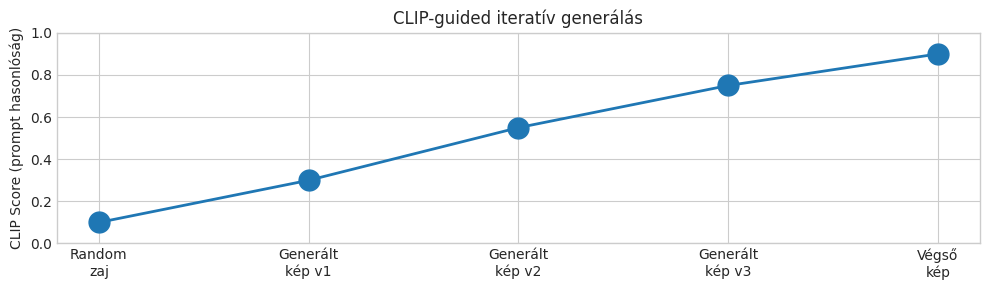

In [7]:
# CLIP használata generatív modellekben
def clip_guidance_demo():
    """
    CLIP-guided generation koncepció.
    """
    print("CLIP-guided képgenerálás:")
    print("="*50)
    print("""
    1. Generálj képet (pl. GAN, Diffusion)
    2. Számold ki a CLIP hasonlóságot a prompt-hoz
    3. Optimalizáld a képet a hasonlóság növelésére
    4. Ismételd amíg konvergál

    Ez a "CLIP guidance" - Stable Diffusion és DALL·E is használja!
    """)

    # Vizualizáció
    fig, ax = plt.subplots(figsize=(10, 3))

    steps = ['Random\nzaj', 'Generált\nkép v1', 'Generált\nkép v2', 'Generált\nkép v3', 'Végső\nkép']
    clip_scores = [0.1, 0.3, 0.55, 0.75, 0.9]

    ax.plot(clip_scores, 'o-', markersize=15, linewidth=2)
    ax.set_xticks(range(len(steps)))
    ax.set_xticklabels(steps)
    ax.set_ylabel('CLIP Score (prompt hasonlóság)')
    ax.set_title('CLIP-guided iteratív generálás', fontsize=12)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

clip_guidance_demo()

## Összefoglalás

### CLIP lényege

1. **Két encoder**: Image + Text → Közös tér
2. **Kontraszt tanulás**: Kép-szöveg párok 400M méretű adaton
3. **Zero-shot**: Új feladatok prompt-tal

### Használat

```python
import clip

model, preprocess = clip.load("ViT-B/32")

# Kép és szöveg encoding
image_features = model.encode_image(image)
text_features = model.encode_text(clip.tokenize(["a dog", "a cat"]))

# Hasonlóság
similarity = (image_features @ text_features.T).softmax(dim=-1)
```

### CLIP variánsok

| Modell | Image Encoder | Params |
|--------|---------------|--------|
| CLIP RN50 | ResNet-50 | 102M |
| CLIP ViT-B/32 | ViT-B/32 | 151M |
| CLIP ViT-L/14 | ViT-L/14 | 428M |
| OpenCLIP | Különböző | Különböző |